In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
#official website
url = "https://data.cityofnewyork.us/resource/ebb7-mvp5.csv?$limit=50000"

waste_data = pd.read_csv(url)

waste_data.shape

(25119, 12)

In [48]:
waste_data.head()

,month,borough,communitydistrict,refusetonscollected,papertonscollected,mgptonscollected,resorganicstons,schoolorganictons,leavesorganictons,xmastreetons,otherorganicstons,borough_id
0,2026 / 06,Bronx,1,3713.76,259.09,149.19,24.09,56.84,NaN,NaN,NaN,2
1,2026 / 06,Bronx,2,8137.73,250.28,202.33,16.31,76.79,NaN,NaN,NaN,2
2,2026 / 06,Bronx,3,2402.16,145.92,149.96,23.89,NaN,NaN,NaN,NaN,2
3,2026 / 06,Bronx,4,4353.46,279.87,304.82,29.82,50.60,NaN,NaN,NaN,2
4,2026 / 06,Bronx,5,3724.98,277.80,319.10,25.13,51.65,NaN,NaN,NaN,2


In [49]:
waste_data.columns

Index(['month', 'borough', 'communitydistrict', 'refusetonscollected',
       'papertonscollected', 'mgptonscollected', 'resorganicstons',
       'schoolorganictons', 'leavesorganictons', 'xmastreetons',
       'otherorganicstons', 'borough_id'],
      dtype='object')

In [50]:
waste_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25119 entries, 0 to 25118
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                25119 non-null  object 
 1   borough              25119 non-null  object 
 2   communitydistrict    25119 non-null  int64  
 3   refusetonscollected  25119 non-null  float64
 4   papertonscollected   22685 non-null  float64
 5   mgptonscollected     23042 non-null  float64
 6   resorganicstons      3567 non-null   float64
 7   schoolorganictons    2606 non-null   float64
 8   leavesorganictons    881 non-null    float64
 9   xmastreetons         1685 non-null   float64
 10  otherorganicstons    1283 non-null   float64
 11  borough_id           25119 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 2.3+ MB


In [51]:
waste_data.isna().sum()

,0
month,0
borough,0
communitydistrict,0
refusetonscollected,0
papertonscollected,2434
mgptonscollected,2077
resorganicstons,21552
schoolorganictons,22513
leavesorganictons,24238
xmastreetons,23434


In [52]:
##

In [53]:
waste_data.duplicated().sum()

np.int64(0)

In [54]:
waste_data["month"].head()

,month
0,2026 / 06
1,2026 / 06
2,2026 / 06
3,2026 / 06
4,2026 / 06


In [55]:
## see the target column
# we choose refusetonscollected as target because it show the amount of general waste collected
# the model will try to predict how many tons of waste will be collected
waste_data["refusetonscollected"].describe()

,refusetonscollected
count,25119.000000
mean,4239.734060
std,1553.653364
min,8.400000
25%,3127.055000
50%,4061.600000
75%,5194.180000
max,10413.890000


In [56]:
# keep only the columns we need .. as shown above alot of missing values.. but we don't really need them in our model
waste_data = waste_data[
    ["month", "borough", "communitydistrict", "refusetonscollected"]
].copy()

In [57]:
#check again
waste_data.isna().sum()

,0
month,0
borough,0
communitydistrict,0
refusetonscollected,0


In [58]:
# some organic waste columns have many missing values
# we do not need them because our target is general waste
# so i keep only the important columns

In [59]:
# change month to date
waste_data["month"] = pd.to_datetime(waste_data["month"], format="%Y / %m")

In [60]:
waste_data["month"].head()

,month
0,2026-06-01
1,2026-06-01
2,2026-06-01
3,2026-06-01
4,2026-06-01


In [61]:
print(waste_data["month"].min())
print(waste_data["month"].max())

1990-01-01 00:00:00
2026-06-01 00:00:00


In [62]:
# check zero or negative waste values
(waste_data["refusetonscollected"] <= 0).sum()

np.int64(0)

In [63]:
# sort data by district and month "لأننا بعدين بنستخدم الاشهر السابقة لتوقع الشهر الجديد"
waste_data = waste_data.sort_values(["borough", "communitydistrict", "month"]).reset_index(drop=True)

In [64]:
waste_data.head()

,month,borough,communitydistrict,refusetonscollected
0,1991-04-01,Bronx,1,18.8
1,1991-05-01,Bronx,1,2596.6
2,1991-06-01,Bronx,1,2492.9
3,1991-07-01,Bronx,1,2626.9
4,1991-08-01,Bronx,1,2538.7


In [65]:
#chnage the target name to simpler name -->
waste_data = waste_data.rename(columns={"refusetonscollected": "waste_tons"})

In [66]:
waste_data.head()

,month,borough,communitydistrict,waste_tons
0,1991-04-01,Bronx,1,18.8
1,1991-05-01,Bronx,1,2596.6
2,1991-06-01,Bronx,1,2492.9
3,1991-07-01,Bronx,1,2626.9
4,1991-08-01,Bronx,1,2538.7


In [67]:
### EDA

monthly_waste = waste_data.groupby("month")["waste_tons"].sum()


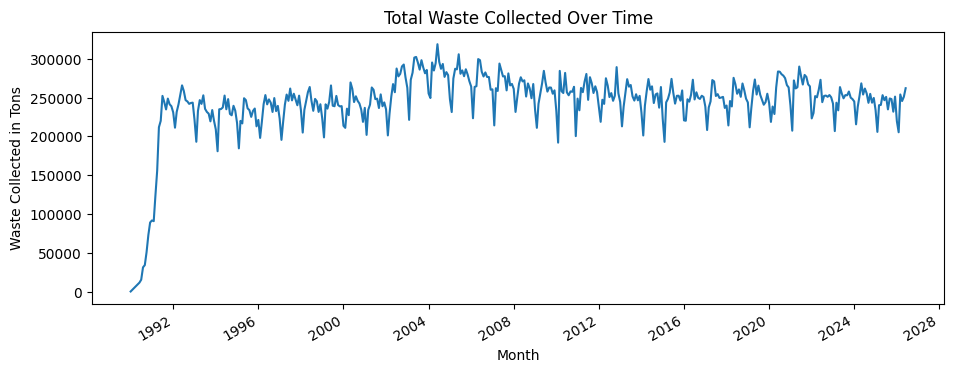

In [68]:
monthly_waste.plot(figsize=(11, 4))

plt.xlabel("Month")
plt.ylabel("Waste Collected in Tons")
plt.title("Total Waste Collected Over Time")
plt.show()

In [69]:
# waste amount was very low before 1992 and the old data may be incomplete
# after 1992 the waste amount became more stable
# the highest waste amount was around 2004 and 2005
# the graph have repeated drops and this may mean there is a seasonal pattern
# in recent years the waste amount is around 250000 tons every month

In [70]:
print(waste_data["month"].max())

2026-06-01 00:00:00


In [71]:
# see the target numbers
waste_data["waste_tons"].describe()

,waste_tons
count,25119.000000
mean,4239.734060
std,1553.653364
min,8.400000
25%,3127.055000
50%,4061.600000
75%,5194.180000
max,10413.890000


In [72]:
# the normal waste amount is around 4000 tons
# most values are between 3000 and 5200 tons
# some rows have very low or very high waste

In [73]:
# compare waste amount between boroughs --> districts
borough_waste = waste_data.groupby("borough")["waste_tons"].mean()

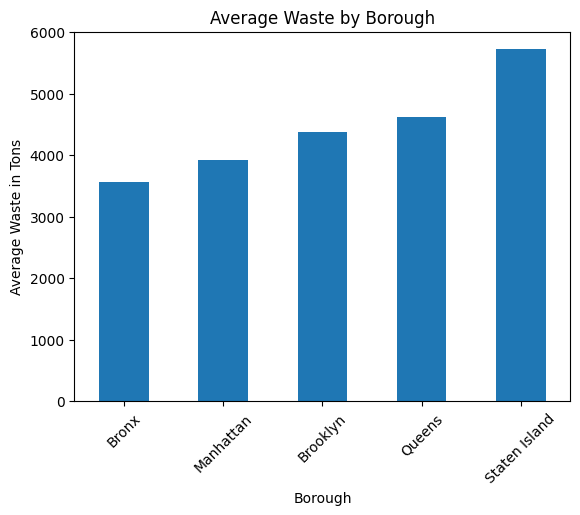

In [74]:
borough_waste.sort_values().plot(kind="bar")

plt.xlabel("Borough")
plt.ylabel("Average Waste in Tons")
plt.title("Average Waste by Borough")
plt.xticks(rotation=45)
plt.show()

In [75]:
# Staten Island have the highest average waste
# Bronx have the lowest average waste
# waste amount is different between boroughs
# borough can help the model prediction
# rhese are the average numbers

In [76]:
# see districts with highest average waste
district_waste = waste_data.groupby(["borough", "communitydistrict"])["waste_tons"].mean()

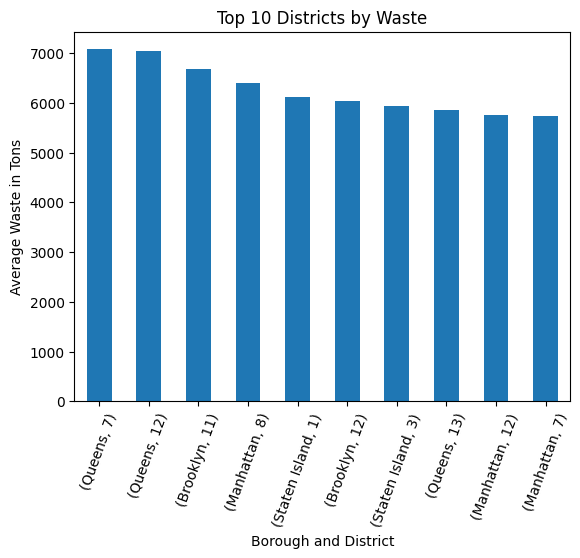

In [77]:
district_waste.sort_values(ascending=False).head(10).plot(kind="bar")

plt.xlabel("Borough and District")
plt.ylabel("Average Waste in Tons")
plt.title("Top 10 Districts by Waste")
plt.xticks(rotation=70)
plt.show()

In [78]:
# Queens district 7 and 12 have the highest average waste
# many of the top districts are from Queens and Brooklyn
# these districts may need more trucks and workers

In [79]:
# does the month also affect the waste tones?

waste_by_month = waste_data.groupby(waste_data["month"].dt.month)["waste_tons"].mean()


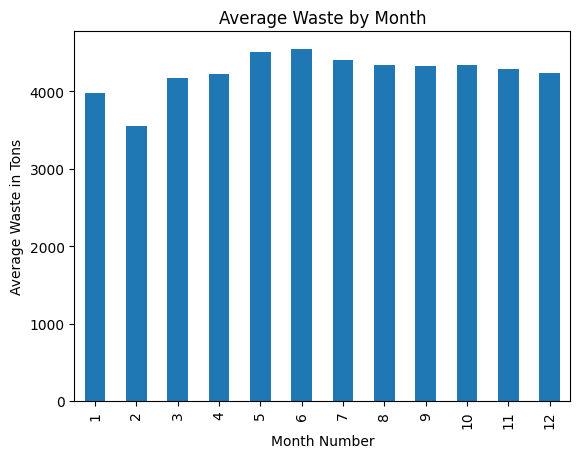

In [80]:
waste_by_month.plot(kind="bar")

plt.xlabel("Month Number")
plt.ylabel("Average Waste in Tons")
plt.title("Average Waste by Month")
plt.show()

In [81]:
# February have the lowest average waste
# May and June have the highest average waste

**Feature Engineering**

In [82]:
# create a year and month number
waste_data["year"] = waste_data["month"].dt.year
waste_data["month_number"] = waste_data["month"].dt.month

In [83]:
# sort every district by month
waste_data = waste_data.sort_values(["borough", "communitydistrict", "month"]).reset_index(drop=True)

In [84]:
# waste amount from last month
waste_data["waste_last_month"] = waste_data.groupby(["borough", "communitydistrict"])["waste_tons"].shift(1)

In [85]:
waste_data.head()

,month,borough,communitydistrict,waste_tons,year,month_number,waste_last_month
0,1991-04-01,Bronx,1,18.8,1991,4,NaN
1,1991-05-01,Bronx,1,2596.6,1991,5,18.8
2,1991-06-01,Bronx,1,2492.9,1991,6,2596.6
3,1991-07-01,Bronx,1,2626.9,1991,7,2492.9
4,1991-08-01,Bronx,1,2538.7,1991,8,2626.9


In [86]:
waste_data["waste_2_months_ago"] = waste_data.groupby( ["borough", "communitydistrict"])["waste_tons"].shift(2)

In [87]:
waste_data.head()

,month,borough,communitydistrict,waste_tons,year,month_number,waste_last_month,waste_2_months_ago
0,1991-04-01,Bronx,1,18.8,1991,4,NaN,NaN
1,1991-05-01,Bronx,1,2596.6,1991,5,18.8,NaN
2,1991-06-01,Bronx,1,2492.9,1991,6,2596.6,18.8
3,1991-07-01,Bronx,1,2626.9,1991,7,2492.9,2596.6
4,1991-08-01,Bronx,1,2538.7,1991,8,2626.9,2492.9


In [88]:
waste_data[
    [
        "month",
        "borough",
        "communitydistrict",
        "waste_tons",
        "waste_last_month",
        "waste_2_months_ago"
    ]
].head(10)

,month,borough,communitydistrict,waste_tons,waste_last_month,waste_2_months_ago
0,1991-04-01,Bronx,1,18.80,NaN,NaN
1,1991-05-01,Bronx,1,2596.60,18.8,NaN
2,1991-06-01,Bronx,1,2492.90,2596.6,18.8
3,1991-07-01,Bronx,1,2626.90,2492.9,2596.6
4,1991-08-01,Bronx,1,2538.70,2626.9,2492.9
5,1991-09-01,Bronx,1,2485.10,2538.7,2626.9
6,1991-10-01,Bronx,1,2628.00,2485.1,2538.7
7,1991-11-01,Bronx,1,2510.70,2628.0,2485.1
8,1991-12-01,Bronx,1,2723.60,2510.7,2628.0
9,1992-01-01,Bronx,1,2462.22,2723.6,2510.7


In [89]:
# check missing values from shift
waste_data[["waste_last_month", "waste_2_months_ago"]].isna().sum()

# its normal to have missing data here because the first two months are the starting point and does not have prev values

,0
waste_last_month,59
waste_2_months_ago,118


In [90]:
waste_data = waste_data.dropna(subset=["waste_last_month", "waste_2_months_ago"])

In [91]:
waste_data[["waste_last_month", "waste_2_months_ago"]].isna().sum()


,0
waste_last_month,0
waste_2_months_ago,0


In [92]:
##Encoding

#sort the data
waste_data = waste_data.sort_values("month").reset_index(drop=True)

In [93]:
#features
#don't put waste_tons inside X
# waste_tons is the answer that the model need to predict
X = waste_data[
    [
        "borough",
        "communitydistrict",
        "year",
        "month_number",
        "waste_last_month",
        "waste_2_months_ago"
    ]
]

#target
y = waste_data["waste_tons"]

In [94]:
# change categories to 0 and 1
X = pd.get_dummies( X,columns=["borough", "communitydistrict"], drop_first=True,dtype=int)

In [95]:
X.head()

,year,month_number,waste_last_month,waste_2_months_ago,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten Island,communitydistrict_2,communitydistrict_3,...,communitydistrict_9,communitydistrict_10,communitydistrict_11,communitydistrict_12,communitydistrict_13,communitydistrict_14,communitydistrict_15,communitydistrict_16,communitydistrict_17,communitydistrict_18
0,1990,7,3485.8,39.1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1990,8,5203.7,3790.0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1990,8,4662.2,3485.8,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1990,8,5377.9,4242.2,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1990,9,5657.5,5377.9,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [96]:
X.shape

(25001, 25)

In [97]:
# Train And test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.20,shuffle=False)

print(X_train.shape)
print(X_test.shape)

(20000, 25)
(5001, 25)


In [101]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [104]:
# The models
# Random Forest = many normal random trees

# Extra Trees = many trees with more random choices

# XGBoost = every new tree try to fix the old errors

In [105]:
forest_model = RandomForestRegressor(n_estimators=100,max_depth=15,random_state=42,n_jobs=-1)




forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

In [102]:
extra_model = ExtraTreesRegressor( n_estimators=100, max_depth=15,random_state=42, n_jobs=-1)

extra_model.fit(X_train, y_train)
extra_pred = extra_model.predict(X_test)

In [103]:
xgb_model = XGBRegressor(n_estimators=200,max_depth=6,learning_rate=0.05,random_state=42)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [106]:
print("Random Forest")
print("MAE:", round(mean_absolute_error(y_test, forest_pred), 2))
print("RMSE:", round(mean_squared_error(y_test, forest_pred) ** 0.5, 2))
print("R2:", round(r2_score(y_test, forest_pred), 2))


Random Forest
MAE: 194.62
RMSE: 281.74
R2: 0.97


In [107]:
print("Extra Trees")
print("MAE:", round(mean_absolute_error(y_test, extra_pred), 2))
print("RMSE:", round(mean_squared_error(y_test, extra_pred) ** 0.5, 2))
print("R2:", round(r2_score(y_test, extra_pred), 2))

Extra Trees
MAE: 193.38
RMSE: 277.53
R2: 0.97


In [108]:
print("XGBoost")
print("MAE:", round(mean_absolute_error(y_test, xgb_pred), 2))
print("RMSE:", round(mean_squared_error(y_test, xgb_pred) ** 0.5, 2))
print("R2:", round(r2_score(y_test, xgb_pred), 2))

XGBoost
MAE: 211.54
RMSE: 295.6
R2: 0.97


In [109]:
# the errors look high because the waste amount is in thousands of tons
# Extra Trees is the best because it have the lowest MAE and RMSE
# the model error is only around 193 tons from about 4000 tons
# R2 is 0.97 so the prediction is very good
# 1 Extra Trees
# 2 Random Forest
# 3 XGBoost

## Final Insights

- Waste amount was very low before 1992. The old data may not be complete.

- After 1992 the waste amount became more stable.

- The highest waste amount was around 2004 and 2005.

- Waste amount is not the same in every borough.

- Staten Island has the highest average waste. Bronx has the lowest average waste.

- Queens district 7 and district 12 have the highest average waste between the districts.

- February has the lowest waste amount. May and June have the highest waste amount.

- The city can use this information to plan more trucks and workers for the months and districts with more waste.